# Exploratory Analysis and Business Visualization

Turns the user-level feature snapshot (`feature_table`) into business-facing charts: data quality checks, derived audience segments, and visual diagnostics of churn, retention, and paid conversion.

Every chart is read with the same discipline: the business question it answers, the dominant pattern, the resulting insight, a candidate action, and its limitations.

## 1. Data Loading

This analysis works from the user-level wide table produced by the SQL pipeline, so only `feature_table` is loaded. The table must be one row per user — duplicated users would inflate every segment share, conversion rate, and churn rate below (verified in the quality checks).

In [1]:
# Environment setup. Data is auto-discovered by src/data_loader.py
# (./data in the repo, /content/data on Colab, or SPOTIFY_DATA_DIR).
import sys
from pathlib import Path

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Seaborn is optional; used for style/statistical charts when available.
# Versions below 0.12 are incompatible with pandas 2 — fall back to matplotlib.
try:
    import seaborn as sns
    if tuple(int(x) for x in sns.__version__.split('.')[:2]) < (0, 12):
        sns = None
except Exception:
    sns = None

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 120)

from src.data_loader import load_table

df_raw = load_table('feature_table')
df_raw.head()

/Users/jackyjiang/opt/anaconda3/lib/python3.9/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
/Users/jackyjiang/opt/anaconda3/lib/python3.9/site-packages/pandas/core/arrays/masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.2' currently installed).
  from pandas.core import (
/Users/jackyjiang/opt/anaconda3/lib/python3.9/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


,user_id,snapshot_date,signup_date,tenure_days,country,language,region_tier,age_group,primary_device,acquisition_channel,student_eligible,marketing_opt_in,music_persona,subscription_type,lifecycle_stage,active_days_7d,listen_events_7d,listen_minutes_7d,active_days_30d,listen_events_30d,listen_minutes_30d,sessions_30d,avg_play_duration_sec_30d,skip_rate_30d,completion_rate_30d,...,top_genre_30d,ad_impressions_30d,ad_clicks_30d,ad_click_rate_30d,ad_completions_30d,ad_completion_rate_30d,ad_impressions_per_active_day,ad_load_bucket,ad_revenue_30d,trial_exposed_30d,trial_started_30d,trial_used_before_snapshot,paid_started_30d,paid_conversion_30d,renewal_success_30d,payment_failed_30d,cancel_30d,trial_expired_30d,renewal_success_14d,subscription_revenue_30d,total_revenue_30d,active_level_30d,listening_level_30d,listen_events_14d,churn_label_14d
0,U000001,2026-04-01,2026-02-06,54,UK,en,Tier 1,35-44,mobile_android,organic_search,0,0,commute_listener,free,casual_free,0.0,0.0,0.0000,1.0,1.0,1.9333,1.0,116.0,0.00,0.0,...,jazz,3.0,0.0,0.0,2.0,0.6667,3.0000,medium,0.0438,0,0,0,0,0,0,0,1,0,0,0.0,0.0438,low,very_low,2,0
1,U000002,2026-04-01,2026-03-07,25,ES,es,Tier 2,25-34,mobile_android,paid_social,0,0,playlist_builder,free,engaged_free,3.0,3.0,7.1167,10.0,10.0,21.5500,10.0,129.3,0.20,0.3,...,rock,7.0,0.0,0.0,6.0,0.8571,0.7000,low,0.0544,1,0,0,0,0,0,0,0,0,0,0.0,0.0544,medium,low,0,1
2,U000003,2026-04-01,2025-07-29,246,IN,en,Tier 2,18-24,mobile_android,referral,0,0,casual_listener,free,casual_free,1.0,1.0,2.6500,3.0,3.0,6.5000,3.0,130.0,0.00,0.0,...,pop,1.0,0.0,0.0,0.0,0.0000,0.3333,low,0.0025,0,0,0,0,0,0,0,0,0,0,0.0,0.0025,low,very_low,0,1
3,U000004,2026-04-01,2025-11-14,138,FR,fr,Tier 1,35-44,mobile_android,referral,0,1,commute_listener,free,casual_free,1.0,1.0,0.6000,4.0,4.0,11.3333,4.0,170.0,0.25,0.0,...,classical,2.0,0.0,0.0,1.0,0.5000,0.5000,low,0.0703,0,0,1,0,0,0,0,0,0,0,0.0,0.0703,medium,low,3,0
4,U000005,2026-04-01,2025-05-21,315,US,en,Tier 1,25-34,mobile_ios,student_partner,1,0,casual_listener,free,casual_free,0.0,0.0,0.0000,1.0,1.0,2.7167,1.0,163.0,0.00,0.0,...,jazz,0.0,0.0,0.0,0.0,0.0000,0.0000,no_ads,0.0000,0,0,0,0,0,0,0,0,0,0,0.0,0.0000,low,very_low,2,0


## 2. Working Columns

Standardize the columns used for charting, fill missing behavioral counts with zero, and derive a `retained_14d` flag. Ad pressure is measured as impressions **per active day** rather than total impressions, since total exposure is confounded by activity level.

In [2]:
df = df_raw.copy()  # work on a copy; keep df_raw as the untouched source

df['device'] = df['primary_device']
df['listen_minutes_30d'] = df['listen_minutes_30d'].fillna(0)
df['playlist_count_30d'] = df['playlist_adds_30d'].fillna(0)
df['liked_song_count_30d'] = df['liked_songs_30d'].fillna(0)
df['search_count_30d'] = df['search_events_30d'].fillna(0)

# Impressions per active day reads as "ad pressure"; raw 30d impressions
# would mostly reflect how active the user is.
df['ad_load_per_active_day'] = df['ad_impressions_per_active_day'].fillna(0)

# Retention flag: 1 - churn. This is "not churned within 14 days",
# not a strict D30 retention definition — keep the caliber in mind.
df['retained_14d'] = 1 - df['churn_label_14d']

df[['user_id', 'device', 'active_days_30d', 'listen_minutes_30d', 'playlist_count_30d',
    'liked_song_count_30d', 'ad_load_per_active_day', 'churn_label_14d', 'retained_14d']].head()

,user_id,device,active_days_30d,listen_minutes_30d,playlist_count_30d,liked_song_count_30d,ad_load_per_active_day,churn_label_14d,retained_14d
0,U000001,mobile_android,1.0,1.9333,0.0,0.0,3.0000,0,1
1,U000002,mobile_android,10.0,21.5500,1.0,1.0,0.7000,1,0
2,U000003,mobile_android,3.0,6.5000,0.0,0.0,0.3333,1,0
3,U000004,mobile_android,4.0,11.3333,0.0,0.0,0.5000,0,1
4,U000005,mobile_ios,1.0,2.7167,0.0,0.0,0.0000,0,1


## 3. Data Quality Checks

Charts are only as trustworthy as the table beneath them. Four checks before plotting: the data loaded at the expected scale, the table is one row per user, key columns have acceptable missing rates, and overall label levels are plausible. If `user_id` duplicates are non-zero, stop and re-check the wide-table JOINs before reading any chart.

In [3]:
print("Rows and columns:", df.shape)  # expected scale: ~50k users

print("Duplicated user_id:", df['user_id'].duplicated().sum())  # must be 0

key_cols = [
    'user_id',
    'device',
    'subscription_type',
    'active_days_30d',
    'listen_minutes_30d',
    'playlist_count_30d',
    'liked_song_count_30d',
    'ad_impressions_30d',
    'ad_load_per_active_day',
    'trial_exposed_30d',
    'trial_started_30d',
    'paid_conversion_30d',
    'churn_label_14d',
    'retained_14d'
]

missing_rate = df[key_cols].isnull().mean().sort_values(ascending=False)
print("Missing rate for key columns:")
display(missing_rate.to_frame('missing_rate'))

label_summary = pd.DataFrame({
    'metric': ['churn_rate_14d', 'paid_conversion_rate_30d', 'retained_rate_14d'],
    'value': [
        df['churn_label_14d'].mean(),   # mean of a 0/1 label is the rate
        df['paid_conversion_30d'].mean(),
        df['retained_14d'].mean()
    ]
})

display(label_summary)  # baseline reference for all segment charts below

Rows and columns: (50000, 59)
Duplicated user_id: 0
Missing rate for key columns:


,missing_rate
user_id,0.0
device,0.0
subscription_type,0.0
active_days_30d,0.0
listen_minutes_30d,0.0
playlist_count_30d,0.0
liked_song_count_30d,0.0
ad_impressions_30d,0.0
ad_load_per_active_day,0.0
trial_exposed_30d,0.0


,metric,value
0,churn_rate_14d,0.47558
1,paid_conversion_rate_30d,0.17392
2,retained_rate_14d,0.52442


## 4. Derived Segments

Stakeholders discuss populations, not continuous columns — low-activity users, high-ad-pressure users, content-engaged users. Three derived segments drive the charts:

- `active_level` — whether a usage habit has formed.
- `content_engaged` — whether the user is building content assets (playlists, liked songs).
- `ad_load_bucket_viz` — how much ad pressure the user experiences.

The ad buckets use impressions per active day, not total impressions: high-activity users naturally see more ads, so total exposure would conflate activity with pressure.

In [4]:
# 1. Activity level. Thresholds follow the project's framing: <=3 days means
# no habit formed, 4-10 days some usage, >10 days stable usage.
df['active_level'] = pd.cut(
    df['active_days_30d'],
    bins=[-1, 3, 10, 31],
    labels=['low', 'medium', 'high']
)

# 2. Content engagement: any playlist add or liked song counts. Closer to
# "stickiness" than listening time alone — content assets raise switching costs.
df['content_engaged'] = np.where(
    (df['playlist_count_30d'] > 0) | (df['liked_song_count_30d'] > 0),
    'content_engaged',
    'no_content_engagement'
)

# 3. Ad load bucket for visualization: keep no_ads separate, then split exposed
# users into terciles of impressions per active day.
df['ad_load_bucket_viz'] = 'no_ads'
mask_ad = df['ad_load_per_active_day'] > 0

df.loc[mask_ad, 'ad_load_bucket_viz'] = pd.qcut(
    df.loc[mask_ad, 'ad_load_per_active_day'],
    q=3,
    labels=['low', 'medium', 'high'],
    duplicates='drop'  # degrade gracefully if tercile edges collide
).astype(str)

display(df[['active_days_30d', 'active_level', 'playlist_count_30d', 'liked_song_count_30d',
            'content_engaged', 'ad_load_per_active_day', 'ad_load_bucket_viz']].head())

# Segment sizes — small groups make the downstream charts unreliable.
print("Active level distribution:")
display(df['active_level'].value_counts(dropna=False).to_frame('users'))

print("Content engagement distribution:")
display(df['content_engaged'].value_counts(dropna=False).to_frame('users'))

print("Ad load bucket distribution:")
display(df['ad_load_bucket_viz'].value_counts(dropna=False).to_frame('users'))

,active_days_30d,active_level,playlist_count_30d,liked_song_count_30d,content_engaged,ad_load_per_active_day,ad_load_bucket_viz
0,1.0,low,0.0,0.0,no_content_engagement,3.0000,high
1,10.0,medium,1.0,1.0,content_engaged,0.7000,medium
2,3.0,low,0.0,0.0,no_content_engagement,0.3333,low
3,4.0,medium,0.0,0.0,no_content_engagement,0.5000,medium
4,1.0,low,0.0,0.0,no_content_engagement,0.0000,no_ads


Active level distribution:


,users
active_level,
low,20952
medium,18135
high,10913


Content engagement distribution:


,users
content_engaged,
no_content_engagement,27255
content_engaged,22745


Ad load bucket distribution:


,users
ad_load_bucket_viz,
no_ads,20436
medium,12816
low,9904
high,6844


## 5. Chart Helper

A shared labeling helper keeps the charts consistent and self-explanatory: clear titles, labeled axes, and explicit values on bars. Readability beats decoration.

In [5]:
def add_bar_labels(ax, fmt='{:.1%}'):
    """Add value labels above bars."""
    for patch in ax.patches:
        height = patch.get_height()
        if pd.isna(height):
            continue
        ax.text(
            patch.get_x() + patch.get_width() / 2,
            height,
            fmt.format(height),
            ha='center',
            va='bottom',
            fontsize=9
        )

## 6. Baseline: Churn, Conversion, and Retention

**Question.** What are the current overall churn, retention, and conversion levels?

**Why first.** This is the reference line for every segment analysis that follows — without a baseline, no segment can be called high or low.

**Reading.** Segments whose churn sits clearly above this baseline become the priority diagnostic targets.

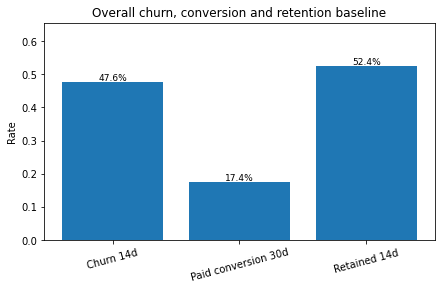

,metric,value
0,Churn 14d,0.47558
1,Paid conversion 30d,0.17392
2,Retained 14d,0.52442


In [6]:
overview = pd.DataFrame({
    'metric': ['Churn 14d', 'Paid conversion 30d', 'Retained 14d'],
    'value': [
        df['churn_label_14d'].mean(),
        df['paid_conversion_30d'].mean(),
        df['retained_14d'].mean()
    ]
})
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(overview['metric'], overview['value'])
ax.set_title('Overall churn, conversion and retention baseline')
ax.set_ylabel('Rate')
ax.set_ylim(0, max(overview['value'] * 1.25))
add_bar_labels(ax, fmt='{:.1%}')
plt.xticks(rotation=15)
plt.show()

display(overview)

## 7. Activity Level vs. Churn

**Question.** Are low-activity users more likely to churn?

**Why.** Retention on a music platform comes from usage habit; active days are its core signal. Conversion rate is included because high-activity free users are also the natural upsell audience.

**Reading.** If churn is clearly higher for the low-activity group, low activity works as an early churn-risk signal; if conversion rises with activity, engaged free users are the conversion target.

**Action.** Onboarding and content recommendations for low-activity users; trial exposure and premium-benefit messaging for high-activity free users.

**Limitation.** Correlational — it does not prove low activity causes churn.

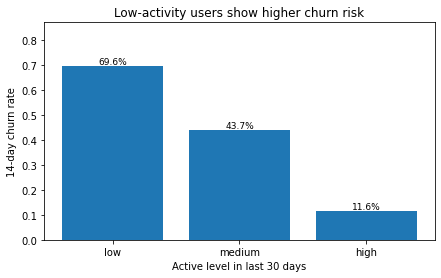

,active_level,users,churn_rate,conversion_rate,avg_listen_minutes
0,low,20952,0.696067,0.120895,6.153741
1,medium,18135,0.437441,0.182244,35.280734
2,high,10913,0.115642,0.261889,106.093311


In [7]:
active_summary = (
    df.groupby('active_level', observed=False)
      .agg(
          users=('user_id', 'count'),
          churn_rate=('churn_label_14d', 'mean'),
          conversion_rate=('paid_conversion_30d', 'mean'),
          avg_listen_minutes=('listen_minutes_30d', 'mean')
      )
      .reset_index()
)
fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(active_summary['active_level'].astype(str), active_summary['churn_rate'])
ax.set_title('Low-activity users show higher churn risk')
ax.set_xlabel('Active level in last 30 days')
ax.set_ylabel('14-day churn rate')
ax.set_ylim(0, active_summary['churn_rate'].max() * 1.25)
add_bar_labels(ax, fmt='{:.1%}')
plt.show()

display(active_summary)

## 8. Subscription Conversion Funnel

**Question.** Why do free/trial users fail to convert, and at which step?

**Why these fields.** `active_days_30d` marks basic habit formation, `trial_exposed_30d` whether the user saw the trial entry point, `trial_started_30d` whether they started one, `paid_conversion_30d` whether they paid within the next 30 days.

**Reading.** A funnel is read for its break point, not for the fact that counts decrease — different break points imply different fixes.

**Action.** A large drop from engaged to trial-exposed points at entry-point placement; a large drop from trial-started to paid points at pricing and benefit communication.

**Limitation.** The exposure-to-conversion relationship is not causal; it needs A/B testing to confirm.

In [8]:
free_df = df[df['subscription_type'].isin(['free', 'trial'])].copy()  # conversion analysis targets free/trial users

funnel = pd.DataFrame({
    'step': [
        'Free / trial users',
        'Engaged free users',   # basic usage habit formed
        'Trial exposed',
        'Trial started',
        'Paid converted'
    ],
    'users': [
        free_df['user_id'].nunique(),
        free_df.loc[free_df['active_days_30d'] >= 4, 'user_id'].nunique(),
        free_df.loc[free_df['trial_exposed_30d'] == 1, 'user_id'].nunique(),
        free_df.loc[free_df['trial_started_30d'] == 1, 'user_id'].nunique(),
        free_df.loc[free_df['paid_conversion_30d'] == 1, 'user_id'].nunique()
    ]
})

display(funnel)

,step,users
0,Free / trial users,31255
1,Engaged free users,15742
2,Trial exposed,7203
3,Trial started,2681
4,Paid converted,30


## 9. Ad Load vs. Churn

**Question.** Does ad pressure hurt retention?

**Why per-active-day.** Total impressions are confounded by activity — high-activity users naturally see more ads. Impressions per active day is closer to the pressure a user actually feels. The comparison is restricted to free/trial users, whom ads primarily affect.

**Reading.** Higher churn in the high-ad-load bucket flags ads as an experience risk; a flat trend means activity level still needs to be controlled for.

**Action.** Frequency capping for new, low-activity, or trial users; ad-free benefits as a conversion lever for high-activity free users.

**Limitation.** Observational — it cannot prove ads cause churn.

In [9]:
ad_summary = (
    df[df['subscription_type'].isin(['free', 'trial'])]
      .groupby('ad_load_bucket_viz')
      .agg(
          users=('user_id', 'count'),
          churn_rate=('churn_label_14d', 'mean'),
          avg_ad_load=('ad_load_per_active_day', 'mean'),
          avg_active_days=('active_days_30d', 'mean')  # check for residual activity confounding
      )
      .reset_index()
)

display(ad_summary)

,ad_load_bucket_viz,users,churn_rate,avg_ad_load,avg_active_days
0,high,6840,0.531140,1.850846,6.117544
1,low,4030,0.467990,0.306165,7.385360
2,medium,12482,0.496715,0.765592,6.811328
3,no_ads,7903,0.768063,0.000000,0.826522


## 10. Content Engagement vs. Retention

**Question.** Are playlists and liked songs associated with stronger stickiness?

**Why.** Content interactions mean the user is building personal content assets, not just passively listening — and the more assets, the higher the cost of leaving.

**Reading.** A higher retained rate among content-engaged users marks content assets as a key retention signal.

**Action.** Onboarding that drives the first liked song or first playlist, or auto-generated personalized playlists.

**Limitation.** High-intent users are more likely to build playlists in the first place — selection effect, not proof of causation.

In [10]:
content_summary = (
    df.groupby('content_engaged')
      .agg(
          users=('user_id', 'count'),
          churn_rate=('churn_label_14d', 'mean'),
          retained_rate=('retained_14d', 'mean'),
          avg_playlist=('playlist_count_30d', 'mean'),
          avg_liked_songs=('liked_song_count_30d', 'mean')
      )
      .reset_index()
)

display(content_summary)

,content_engaged,users,churn_rate,retained_rate,avg_playlist,avg_liked_songs
0,content_engaged,22745,0.293515,0.706485,1.062871,1.532293
1,no_content_engagement,27255,0.627518,0.372482,0.000000,0.000000


## 11. Device vs. Paid Conversion

**Question.** Which device platform converts best?

**Why.** Devices proxy usage contexts; mobile, desktop, and web can have different conversion paths.

**Reading.** When one device converts better, check active days and churn alongside it to separate "better product experience" from "different user mix".

**Action.** Prioritize the premium entry point on high-potential devices; audit the payment path and benefit display on high-activity but low-converting ones.

**Limitation.** Device differences may be confounded by country, channel, and activity — further stratification needed.

,device,users,conversion_rate,churn_rate,avg_active_days
2,mobile_ios,19806,0.191053,0.469959,6.460265
1,mobile_android,17510,0.171559,0.478698,6.411936
3,smart_speaker,1545,0.170227,0.456311,6.779288
0,desktop,6548,0.151344,0.482132,6.406995
4,web,4591,0.142453,0.485080,6.335003


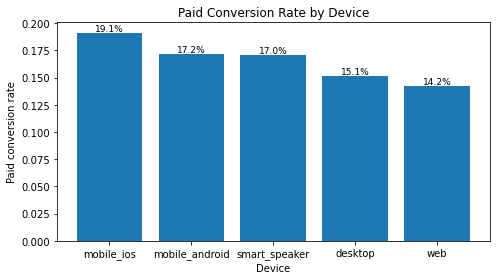

In [11]:
device_summary = (
    df.groupby('device', observed=False)
      .agg(
          users=('user_id', 'nunique'),
          conversion_rate=('paid_conversion_30d', 'mean'),
          churn_rate=('churn_label_14d', 'mean'),
          avg_active_days=('active_days_30d', 'mean')
      )
      .reset_index()
      .sort_values('conversion_rate', ascending=False)
)

display(device_summary)

plt.figure(figsize=(7, 4))
ax = plt.gca()
plt.bar(device_summary['device'].astype(str), device_summary['conversion_rate'])
plt.title('Paid Conversion Rate by Device')
plt.xlabel('Device')
plt.ylabel('Paid conversion rate')
add_bar_labels(ax, fmt='{:.1%}')
plt.tight_layout()
plt.show()

## 12. Distribution of Listening Minutes

**Question.** Is listening time concentrated in a small set of heavy users?

**Why.** The bar charts above compare segment means, which extreme users can distort. A histogram shows the full shape of `listen_minutes_30d`; values are capped at the 99th percentile so outliers don't compress the axis.

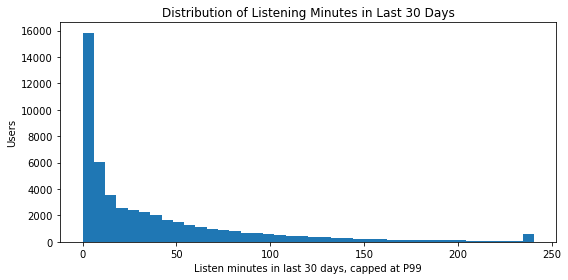

In [12]:
p99_listen = df['listen_minutes_30d'].quantile(0.99)
df['listen_minutes_30d_capped'] = df['listen_minutes_30d'].clip(upper=p99_listen)

plt.figure(figsize=(8, 4))
plt.hist(df['listen_minutes_30d_capped'].dropna(), bins=40)
plt.title('Distribution of Listening Minutes in Last 30 Days')
plt.xlabel('Listen minutes in last 30 days, capped at P99')
plt.ylabel('Users')
plt.tight_layout()
plt.show()

## 13. Listening Minutes by Subscription Type

**Question.** Do free, trial, and paid users really differ in usage depth?

**Why.** Averages hide distributional differences. A boxplot compares medians, quartiles, and spread of `listen_minutes_30d` across subscription types in one view.

,subscription_type,users,avg_listen_minutes,median_listen_minutes,p25_listen_minutes,p75_listen_minutes
0,family_premium,3247,53.339734,32.4000,8.12500,77.42500
3,student_premium,943,54.044715,32.2500,9.29165,76.00000
2,individual_premium,14555,52.462707,31.1500,8.10000,75.01665
4,trial,1249,37.570256,19.6167,4.66670,52.90000
1,free,30006,29.722967,11.0000,2.66670,39.90000


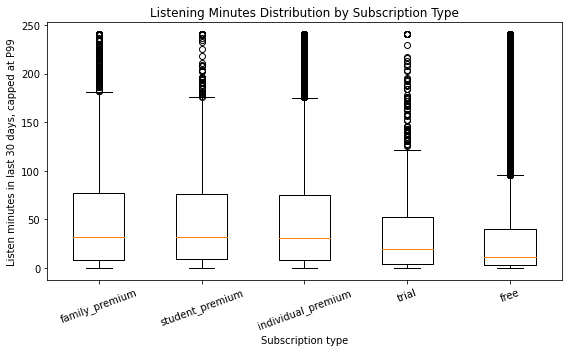

In [13]:
box_df = df[['user_id', 'subscription_type', 'listen_minutes_30d']].dropna(
    subset=['subscription_type', 'listen_minutes_30d']
).copy()

p99 = box_df['listen_minutes_30d'].quantile(0.99)
box_df['listen_minutes_30d_capped'] = box_df['listen_minutes_30d'].clip(upper=p99)

subscription_summary = (
    box_df.groupby('subscription_type')
          .agg(
              users=('user_id', 'nunique'),
              avg_listen_minutes=('listen_minutes_30d', 'mean'),
              median_listen_minutes=('listen_minutes_30d', 'median'),
              p25_listen_minutes=('listen_minutes_30d', lambda x: x.quantile(0.25)),
              p75_listen_minutes=('listen_minutes_30d', lambda x: x.quantile(0.75))
          )
          .reset_index()
          .sort_values('median_listen_minutes', ascending=False)
)

display(subscription_summary)

subscription_order = subscription_summary['subscription_type'].tolist()

plt.figure(figsize=(8, 5))

if sns is not None:
    sns.boxplot(
        data=box_df,
        x='subscription_type',
        y='listen_minutes_30d_capped',
        order=subscription_order
    )
else:
    data_to_plot = [
        box_df.loc[box_df['subscription_type'] == s, 'listen_minutes_30d_capped']
        for s in subscription_order
    ]
    plt.boxplot(data_to_plot, labels=subscription_order)

plt.title('Listening Minutes Distribution by Subscription Type')
plt.xlabel('Subscription type')
plt.ylabel('Listen minutes in last 30 days, capped at P99')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

## 14. Top Genres: Retention and Conversion

**Question.** Do users with different music preferences retain or convert differently?

**Why.** `top_genre_30d` captures content preference; genre-level differences inform recommendations, playlist operations, and how premium benefits get packaged. Genres with too few users are filtered out to avoid noisy rates.

,top_genre_30d,users,retained_rate,churn_rate,conversion_rate
10,pop,10928,0.661878,0.338122,0.210469
11,rock,2798,0.567548,0.432452,0.179771
3,hip_hop,7757,0.565167,0.434833,0.184479
8,news_podcast,2364,0.556261,0.443739,0.194162
7,latin,3143,0.551702,0.448298,0.167674
12,true_crime_podcast,1003,0.543370,0.456630,0.163509
1,comedy_podcast,4447,0.534967,0.465033,0.171576
6,k_pop,1757,0.519636,0.480364,0.154240
4,indie,2782,0.509346,0.490654,0.164989
2,edm,4436,0.495942,0.504058,0.178765


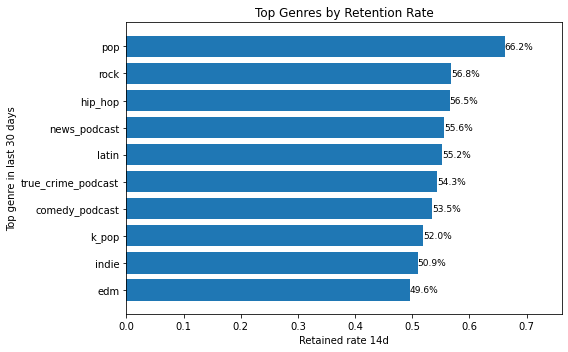

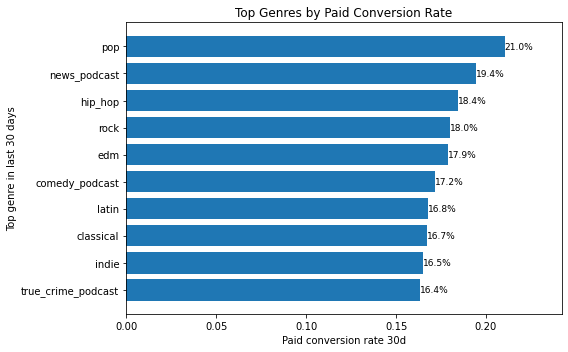

In [14]:
genre_df = df[[
    'user_id',
    'top_genre_30d',
    'retained_14d',
    'churn_label_14d',
    'paid_conversion_30d'
]].dropna(subset=['top_genre_30d']).copy()

genre_df = genre_df[
    ~genre_df['top_genre_30d'].astype(str).str.lower().isin(['unknown', 'none', 'nan'])
].copy()

genre_summary = (
    genre_df.groupby('top_genre_30d')
            .agg(
                users=('user_id', 'nunique'),
                retained_rate=('retained_14d', 'mean'),
                churn_rate=('churn_label_14d', 'mean'),
                conversion_rate=('paid_conversion_30d', 'mean')
            )
            .reset_index()
)

min_users = 300
genre_summary_filtered = genre_summary[genre_summary['users'] >= min_users].copy()
genre_summary_filtered = genre_summary_filtered.sort_values('retained_rate', ascending=False)

display(genre_summary_filtered)

top_retention = (
    genre_summary_filtered
    .sort_values('retained_rate', ascending=True)
    .tail(10)
)

plt.figure(figsize=(8, 5))
plt.barh(top_retention['top_genre_30d'].astype(str), top_retention['retained_rate'])
plt.title('Top Genres by Retention Rate')
plt.xlabel('Retained rate 14d')
plt.ylabel('Top genre in last 30 days')
plt.xlim(0, top_retention['retained_rate'].max() * 1.15)

for i, value in enumerate(top_retention['retained_rate']):
    plt.text(value, i, f'{value:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

top_conversion = (
    genre_summary_filtered
    .sort_values('conversion_rate', ascending=True)
    .tail(10)
)

plt.figure(figsize=(8, 5))
plt.barh(top_conversion['top_genre_30d'].astype(str), top_conversion['conversion_rate'])
plt.title('Top Genres by Paid Conversion Rate')
plt.xlabel('Paid conversion rate 30d')
plt.ylabel('Top genre in last 30 days')
plt.xlim(0, top_conversion['conversion_rate'].max() * 1.15)

for i, value in enumerate(top_conversion['conversion_rate']):
    plt.text(value, i, f'{value:.1%}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

## 15. Acquisition Channel Quality

**Question.** Which channels bring higher-quality users?

**Why.** Channel evaluation cannot stop at volume: conversion, churn, and activity separate channels that are merely large from channels that are actually good. High-volume channels are not necessarily high-quality, and high-conversion channels may not scale.

,acquisition_channel,users,conversion_rate,churn_rate,avg_active_days
5,referral,6495,0.228022,0.361047,7.441416
6,student_partner,3975,0.186918,0.471447,6.705157
2,influencer,4036,0.186323,0.457136,6.629584
0,app_store,12534,0.175762,0.467449,6.513643
1,email_campaign,2023,0.173505,0.468611,6.542758
3,organic_search,11944,0.170295,0.459729,6.568905
4,paid_social,8993,0.125876,0.602357,5.188146


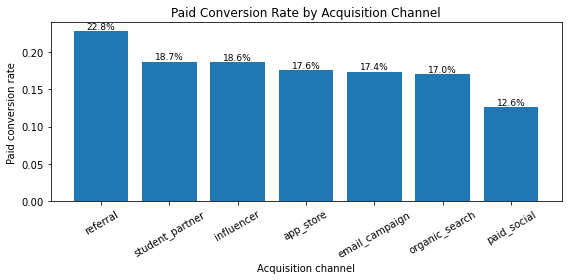

In [15]:
channel_summary = (
    df.groupby('acquisition_channel')
      .agg(
          users=('user_id', 'nunique'),
          conversion_rate=('paid_conversion_30d', 'mean'),
          churn_rate=('churn_label_14d', 'mean'),
          avg_active_days=('active_days_30d', 'mean')
      )
      .reset_index()
      .sort_values('conversion_rate', ascending=False)
)

display(channel_summary)

plt.figure(figsize=(8, 4))
ax = plt.gca()
plt.bar(channel_summary['acquisition_channel'].astype(str), channel_summary['conversion_rate'])
plt.title('Paid Conversion Rate by Acquisition Channel')
plt.xlabel('Acquisition channel')
plt.ylabel('Paid conversion rate')
plt.xticks(rotation=30)
add_bar_labels(ax, fmt='{:.1%}')
plt.tight_layout()
plt.show()

## 16. Active Days vs. Listening Minutes

**Question.** Do active days and listening minutes move together, and are there unusual usage patterns?

**Why.** Both measure engagement but mean different things: some users listen briefly every day, others rarely but for long sessions. A scatter plot (sampled to 3,000 users, minutes capped at P99) surfaces these modes and how they relate to churn.

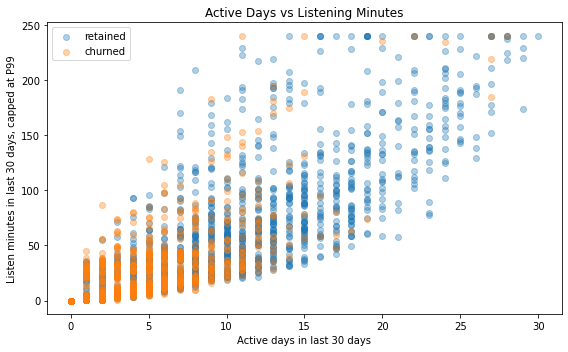

In [16]:
scatter_df = df[[
    'user_id',
    'active_days_30d',
    'listen_minutes_30d',
    'churn_label_14d'
]].dropna().copy()

p99 = scatter_df['listen_minutes_30d'].quantile(0.99)
scatter_df['listen_minutes_30d_capped'] = scatter_df['listen_minutes_30d'].clip(upper=p99)

scatter_sample = scatter_df.sample(
    n=min(3000, len(scatter_df)),
    random_state=42
)

plt.figure(figsize=(8, 5))

if sns is not None:
    sns.scatterplot(
        data=scatter_sample,
        x='active_days_30d',
        y='listen_minutes_30d_capped',
        hue='churn_label_14d',
        alpha=0.45
    )
else:
    retained = scatter_sample[scatter_sample['churn_label_14d'] == 0]
    churned = scatter_sample[scatter_sample['churn_label_14d'] == 1]
    plt.scatter(retained['active_days_30d'], retained['listen_minutes_30d_capped'], alpha=0.35, label='retained')
    plt.scatter(churned['active_days_30d'], churned['listen_minutes_30d_capped'], alpha=0.35, label='churned')
    plt.legend()

plt.title('Active Days vs Listening Minutes')
plt.xlabel('Active days in last 30 days')
plt.ylabel('Listen minutes in last 30 days, capped at P99')
plt.tight_layout()
plt.show()

## 17. Signup Cohort Trends

**Question.** Is user quality stable across signup months?

**Why.** An aggregate churn rate can hide cohort differences: a weak month may reflect declining channel quality, low-quality campaign traffic, or an onboarding regression. Retention and conversion are tracked by signup month to catch such shifts.

,signup_month,users,churn_rate,retained_rate,conversion_rate
0,2025-01,1370,0.470803,0.529197,0.146715
1,2025-02,2098,0.451382,0.548618,0.149666
2,2025-03,2571,0.453520,0.546480,0.150525
3,2025-04,3027,0.476049,0.523951,0.162868
4,2025-05,3281,0.478817,0.521183,0.153307
5,2025-06,3439,0.482408,0.517592,0.154696
6,2025-07,3886,0.468091,0.531909,0.146423
7,2025-08,4000,0.483000,0.517000,0.157750
8,2025-09,3960,0.468939,0.531061,0.157323
9,2025-10,4236,0.464353,0.535647,0.162417


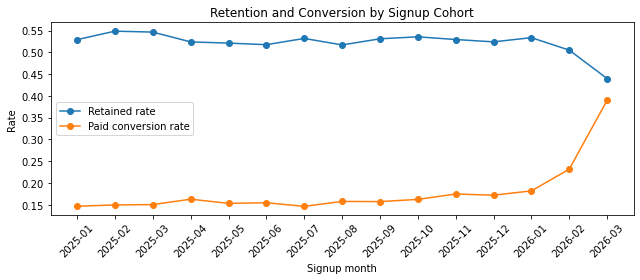

In [17]:
cohort_df = df[[
    'user_id',
    'signup_date',
    'churn_label_14d',
    'retained_14d',
    'paid_conversion_30d'
]].dropna(subset=['signup_date']).copy()

cohort_df['signup_month'] = pd.to_datetime(cohort_df['signup_date']).dt.to_period('M').astype(str)

cohort_summary = (
    cohort_df.groupby('signup_month')
             .agg(
                 users=('user_id', 'nunique'),
                 churn_rate=('churn_label_14d', 'mean'),
                 retained_rate=('retained_14d', 'mean'),
                 conversion_rate=('paid_conversion_30d', 'mean')
             )
             .reset_index()
             .sort_values('signup_month')
)

display(cohort_summary)

plt.figure(figsize=(9, 4))
# .to_numpy() keeps this compatible across matplotlib versions
months = cohort_summary['signup_month'].to_numpy()
plt.plot(months, cohort_summary['retained_rate'].to_numpy(), marker='o', label='Retained rate')
plt.plot(months, cohort_summary['conversion_rate'].to_numpy(), marker='o', label='Paid conversion rate')
plt.title('Retention and Conversion by Signup Cohort')
plt.xlabel('Signup month')
plt.ylabel('Rate')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()